<a href="https://colab.research.google.com/github/hvjha/AWA/blob/PROJECT/Financial_Risk_Analysis_with_Python_Barclays.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install required packages
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost plotly -q

In [4]:
import pandas as pd

In [5]:
from google.colab import files
files.upload()   # Select barclays_transactional_data.csv from your computer



Saving Barclays Financial Transactional Data.xlsx to Barclays Financial Transactional Data.xlsx


{'Barclays Financial Transactional Data.xlsx': b'PK\x03\x04\x14\x00\x08\x08\x08\x00\xdc\x1e\x9d[\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x18\x00\x00\x00xl/drawings/drawing1.xml\x9d\xd0]n\xc20\x0c\x07\xf0\x13\xec\x0eU\xdeiZ\x18\x13C\x14^\xd0N0\x0e\xe0%n\x1b\x91\x8f\xca\x0e\xa3\xdc~\xd1J6i{\x01\x1em\xcb?\xf9\xef\xcdnt\xb6\xf8Db\x13|#\xea\xb2\x12\x05z\x15\xb4\xf1]#\x0e\xefo\xb3\x95(8\x82\xd7`\x83\xc7F\\\x90\xc5n\xfb\xb4\x195\xad\xcf\xbc\xa7"\xed{^\xa7\xb2\x11}\x8c\xc3ZJV=:\xe02\x0c\xe8\xd3\xb4\r\xe4 \xa6\x92:\xa9\t\xceIvV\xce\xab\xeaE\xf2@\x08\x9a{\xc4\xb8\x9f&\xe2\xea\xc1\x03\x9a\x03\xe3\xf3\xfeM\xd7\x84\xb65\n\xf7A\x9d\x1c\xfa8!\x84\x16b\xfa\x05\xf7f\xe0\xac\xa9\x07\xaeQ=P\xfc\x01\xc6\x7f\x823\x8a\x02\x876\x96*\xb8\xeb)\xd9HB\xfd<\t8\xfe\x1a\xf5\xdd\xc8R\xbe\xca\xd5_\xc8\xdd\x14\xc7\x01\x1dO\xc3,\xb9Cz\xc8\x87\xb1&^\xbe\x93eFw\xee\x81\xb7h\x03\x1d\x81\xcb\xc8\xb88\xf8\xe3\xdd\xb1*\xc96\xb5(+l\xb1^\xde\xad\xcc\xb3"\xb7_PK\x07\x08\x07bi\x83\x05\x01\x00\x00\x07\x03\x00\x00PK\x03\x0

In [7]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Visualization settings (Colab-friendly)
sns.set_theme(style="darkgrid", palette="husl")
plt.rcParams['figure.figsize'] = (10, 6)

# Load the dataset (from Colab runtime)
df = pd.read_excel('/content/Barclays Financial Transactional Data.xlsx')


print("Dataset loaded successfully!")

# Basic exploration
print(f"\nDataset shape: {df.shape}")

print("\nFirst 5 rows:")
display(df.head())   # better than print() in Colab

print("\nDataset info:")
df.info()


Dataset loaded successfully!

Dataset shape: (800, 15)

First 5 rows:


,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
0,118,CUST3810,ACC49774,Savings,Deposit,Credit Card,Firm D,West,Manager 4,2024-08-01 00:00:00,20664.409820,88483.42208,0.483333,522,29
1,102,CUST3109,ACC96277,Savings,Deposit,Mutual Fund,Firm B,North,Manager 4,17-12-2023,94924.359120,56670.15864,0.788989,686,130
2,151,CUST2626,ACC21429,Credit,Payment,Personal Loan,Firm C,West,Manager 1,22-05-2024,-7871.160407,84968.05587,0.547782,618,157
3,57,CUST3725,ACC48501,Loan,Withdrawal,Credit Card,Firm A,East,Manager 4,24-12-2023,24979.808160,115196.96420,0.125587,803,155
4,113,CUST4258,ACC11285,Loan,Transfer,Home Loan,Firm A,West,Manager 4,15-01-2023,72890.748550,111602.76610,1.048787,657,68



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TransactionID      800 non-null    int64  
 1   CustomerID         800 non-null    object 
 2   AccountID          800 non-null    object 
 3   AccountType        800 non-null    object 
 4   TransactionType    800 non-null    object 
 5   Product            800 non-null    object 
 6   Firm               800 non-null    object 
 7   Region             800 non-null    object 
 8   Manager            800 non-null    object 
 9   TransactionDate    800 non-null    object 
 10  TransactionAmount  800 non-null    float64
 11  AccountBalance     800 non-null    float64
 12  RiskScore          800 non-null    float64
 13  CreditRating       800 non-null    int64  
 14  TenureMonths       800 non-null    int64  
dtypes: float64(3), int64(3), object(9)
memory usage: 93.9+ KB


In [8]:
class DataPreprocessor:
    def __init__(self, df):
        self.df = df.copy()

    def check_missing_values(self):
        """Check for missing values in the dataset"""
        missing_data = pd.DataFrame({
            'Missing Values': self.df.isnull().sum(),
            'Percentage': (self.df.isnull().sum() / len(self.df)) * 100
        })
        return missing_data[missing_data['Missing Values'] > 0]

    def clean_data(self):
        """Clean and preprocess the data"""
        print("Starting data cleaning process...")

        # -------------------------
        # Convert numeric columns
        # -------------------------
        numeric_cols = [
            'transaction_amount',
            'balance_after_transaction'
        ]

        for col in numeric_cols:
            if col in self.df.columns:
                self.df[col] = pd.to_numeric(self.df[col], errors='coerce')

        # -------------------------
        # Handle missing values
        # -------------------------
        # Numerical → median
        for col in self.df.select_dtypes(include=[np.number]).columns:
            if self.df[col].isnull().sum() > 0:
                self.df[col] = self.df[col].fillna(self.df[col].median())

        # Categorical → mode
        for col in self.df.select_dtypes(include=['object']).columns:
            if self.df[col].isnull().sum() > 0:
                self.df[col] = self.df[col].fillna(self.df[col].mode()[0])

        # -------------------------
        # Date handling
        # -------------------------
        if 'transaction_date' in self.df.columns:
            self.df['transaction_date'] = pd.to_datetime(
                self.df['transaction_date'], errors='coerce'
            )

            self.df['transaction_month'] = self.df['transaction_date'].dt.month
            self.df['transaction_day'] = self.df['transaction_date'].dt.day
            self.df['transaction_weekday'] = self.df['transaction_date'].dt.weekday

        # -------------------------
        # Remove outliers safely
        # -------------------------
        if 'transaction_amount' in self.df.columns:
            Q1 = self.df['transaction_amount'].quantile(0.25)
            Q3 = self.df['transaction_amount'].quantile(0.75)
            IQR = Q3 - Q1

            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR

            original_len = len(self.df)
            self.df = self.df[
                (self.df['transaction_amount'] >= lower) &
                (self.df['transaction_amount'] <= upper)
            ]

            print(f"Removed {original_len - len(self.df)} outliers")

        # -------------------------
        # Feature engineering
        # -------------------------
        self.create_derived_features()

        print("Data cleaning completed!")
        return self.df

    def create_derived_features(self):
        """Create new features"""

        if 'transaction_amount' in self.df.columns:
            self.df['transaction_size_category'] = pd.cut(
                self.df['transaction_amount'],
                bins=[0, 100, 500, 1000, np.inf],
                labels=[
                    'Small (<100)',
                    'Medium (100-500)',
                    'Large (500-1000)',
                    'Very Large (>1000)'
                ]
            )

        if 'balance_after_transaction' in self.df.columns:
            self.df['balance_status'] = np.where(
                self.df['balance_after_transaction'] < 0,
                'Overdraft',
                np.where(
                    self.df['balance_after_transaction'] < 100,
                    'Low Balance',
                    'Normal'
                )
            )

        self.df['risk_score'] = self.calculate_risk_score()
        return self.df

    def calculate_risk_score(self):
        """Calculate risk score"""

        score = np.zeros(len(self.df))

        if all(col in self.df.columns for col in
               ['transaction_type', 'transaction_amount', 'balance_after_transaction']):

            score += (
                (self.df['transaction_type'] == 'Debit') &
                (self.df['transaction_amount'] > 1000) &
                (self.df['balance_after_transaction'] < 500)
            ) * 3

            score += (self.df['balance_after_transaction'] < 0) * 2
            score += (self.df['transaction_amount'] > 5000) * 2

        # Normalize 0–10
        if score.max() > 0:
            score = (score / score.max()) * 10

        return score


In [9]:
preprocessor = DataPreprocessor(df)
df_clean = preprocessor.clean_data()

print("\nCleaned dataset info:")
df_clean.info()

print("\nMissing values check:")
display(preprocessor.check_missing_values())


Starting data cleaning process...
Data cleaning completed!

Cleaned dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TransactionID      800 non-null    int64  
 1   CustomerID         800 non-null    object 
 2   AccountID          800 non-null    object 
 3   AccountType        800 non-null    object 
 4   TransactionType    800 non-null    object 
 5   Product            800 non-null    object 
 6   Firm               800 non-null    object 
 7   Region             800 non-null    object 
 8   Manager            800 non-null    object 
 9   TransactionDate    800 non-null    object 
 10  TransactionAmount  800 non-null    float64
 11  AccountBalance     800 non-null    float64
 12  RiskScore          800 non-null    float64
 13  CreditRating       800 non-null    int64  
 14  TenureMonths       800 non-null    int64

,Missing Values,Percentage


In [15]:
# Standardize column names
df_clean = df_clean.rename(columns={
    'AccountType': 'account_type',
    'TransactionType': 'transaction_type',
    'TransactionDate': 'transaction_date',
    'TransactionAmount': 'transaction_amount',
    'AccountBalance': 'account_balance',
    'RiskScore': 'risk_score',
    'CustomerID': 'customer_id'
})

# Convert date
df_clean['transaction_date'] = pd.to_datetime(
    df_clean['transaction_date'], errors='coerce'
)

# Create month feature (required)
df_clean['transaction_month'] = df_clean['transaction_date'].dt.month


In [16]:
df_clean.columns.tolist()


['TransactionID',
 'customer_id',
 'AccountID',
 'account_type',
 'transaction_type',
 'Product',
 'Firm',
 'Region',
 'Manager',
 'transaction_date',
 'transaction_amount',
 'account_balance',
 'risk_score',
 'CreditRating',
 'TenureMonths',
 'risk_score',
 'transaction_month']

In [19]:
# Remove duplicate columns
df_clean = df_clean.loc[:, ~df_clean.columns.duplicated()]

# Verify
df_clean.columns


Index(['TransactionID', 'customer_id', 'AccountID', 'account_type',
       'transaction_type', 'Product', 'Firm', 'Region', 'Manager',
       'transaction_date', 'transaction_amount', 'account_balance',
       'risk_score', 'CreditRating', 'TenureMonths', 'transaction_month'],
      dtype='object')

In [20]:
numeric_cols = ['transaction_amount', 'AccountBalance', 'risk_score']

for col in numeric_cols:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')


In [25]:
df_clean.columns.tolist()

['TransactionID',
 'customer_id',
 'AccountID',
 'account_type',
 'transaction_type',
 'Product',
 'Firm',
 'Region',
 'Manager',
 'transaction_date',
 'transaction_amount',
 'account_balance',
 'risk_score',
 'CreditRating',
 'TenureMonths',
 'transaction_month']

In [21]:
class CustomerBehaviorAnalyzer:
    def __init__(self, df):
        self.df = df.copy()

    def analyze_account_interaction(self):
        print("\n" + "="*60)
        print("CUSTOMER ACCOUNT INTERACTION ANALYSIS")
        print("="*60)

        account_dist = self.df['account_type'].value_counts()

        fig, axes = plt.subplots(2, 2, figsize=(15, 10))

        # Account type distribution
        axes[0, 0].pie(
            account_dist.values,
            labels=account_dist.index,
            autopct='%1.1f%%'
        )
        axes[0, 0].set_title('Distribution of Account Types')

        # Average balance by account type
        avg_balance = self.df.groupby('account_type')['account_balance'].mean()
        axes[0, 1].bar(avg_balance.index, avg_balance.values)
        axes[0, 1].set_title('Average Balance by Account Type')
        axes[0, 1].tick_params(axis='x', rotation=45)

        # Transaction count
        trans_count = self.df.groupby('account_type').size()
        axes[1, 0].bar(trans_count.index, trans_count.values)
        axes[1, 0].set_title('Transaction Count by Account Type')

        # Average risk score
        risk_by_account = self.df.groupby('account_type')['risk_score'].mean()
        axes[1, 1].bar(risk_by_account.index, risk_by_account.values)
        axes[1, 1].set_title('Average Risk Score by Account Type')

        plt.tight_layout()
        plt.show()

        return account_dist

    def analyze_transaction_trends(self):
        print("\n" + "="*60)
        print("TRANSACTION TRENDS ANALYSIS")
        print("="*60)

        monthly_sum = (
            self.df
            .groupby(['transaction_month', 'transaction_type'])['transaction_amount']
            .sum()
            .unstack()
        )

        fig, axes = plt.subplots(1, 2, figsize=(15, 5))

        # Monthly trend
        monthly_sum.plot(marker='o', ax=axes[0])
        axes[0].set_title('Monthly Transaction Volume')
        axes[0].set_xlabel('Month')
        axes[0].set_ylabel('Amount')

        # Transaction type distribution
        trans_dist = self.df['transaction_type'].value_counts()
        axes[1].pie(
            trans_dist.values,
            labels=trans_dist.index,
            autopct='%1.1f%%'
        )
        axes[1].set_title('Transaction Type Distribution')

        plt.tight_layout()
        plt.show()

        return monthly_sum

    def customer_segmentation_analysis(self):
        print("\n" + "="*60)
        print("CUSTOMER RISK & VALUE ANALYSIS")
        print("="*60)

        segment_stats = self.df.groupby('account_type').agg({
            'transaction_amount': ['mean', 'sum', 'count'],
            'account_balance': ['mean', 'min', 'max'],
            'risk_score': 'mean'
        }).round(2)

        display(segment_stats)
        return segment_stats



CUSTOMER ACCOUNT INTERACTION ANALYSIS


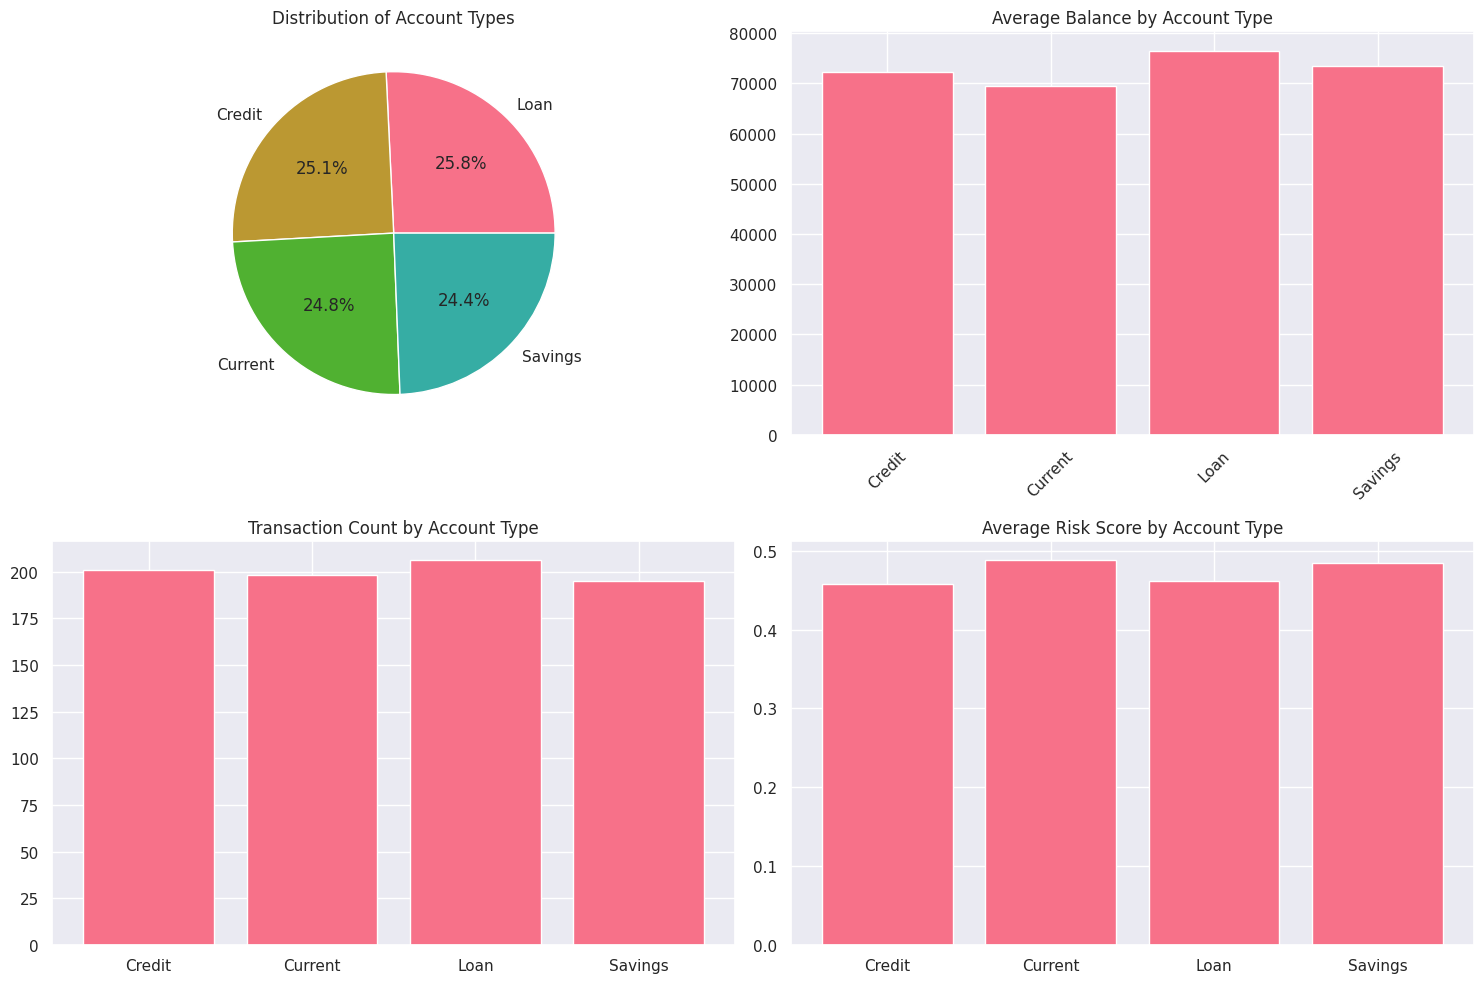


TRANSACTION TRENDS ANALYSIS


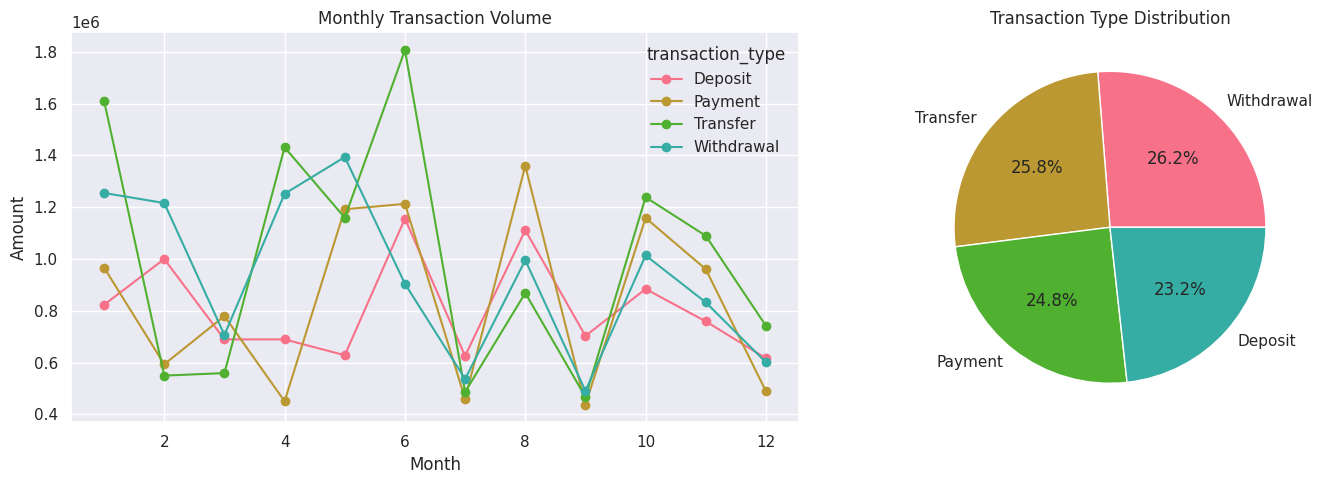


CUSTOMER RISK & VALUE ANALYSIS


transaction_amount                    account_balance            \
                           mean          sum count            mean       min   
account_type                                                                   
Credit                 51481.44  10347769.14   201        72212.27 -17751.22   
Current                53914.74  10675118.86   198        69405.05  -1065.04   
Loan                   55384.37  11409179.98   206        76521.48 -30766.91   
Savings                53969.24  10524001.40   195        73415.11 -14999.18   

                        risk_score  
                    max       mean  
account_type                        
Credit        166960.80       0.46  
Current       150287.80       0.49  
Loan          184008.26       0.46  
Savings       155614.30       0.48

In [22]:
analyzer = CustomerBehaviorAnalyzer(df_clean)

account_interaction = analyzer.analyze_account_interaction()
transaction_trends = analyzer.analyze_transaction_trends()
segment_analysis = analyzer.customer_segmentation_analysis()


In [40]:
class RiskAnalyzer:
    def __init__(self, df):
        self.df = df

    def identify_high_risk_accounts(self):
        print("\n" + "="*60)
        print("HIGH RISK ACCOUNT IDENTIFICATION")
        print("="*60)

        customer_risk_metrics = self.df.groupby('customer_id').agg({
            'risk_score': ['max', 'mean'],
            'account_balance': ['min', 'mean'],
            'transaction_amount': ['std', 'mean'],
            'transaction_type': lambda x: (x == 'Debit').sum() / len(x)
        }).round(2)

        customer_risk_metrics.columns = [
            '_'.join(col).strip() for col in customer_risk_metrics.columns
        ]

        customer_risk_metrics['overdraft_flag'] = (
            customer_risk_metrics['account_balance_min'] < 0
        ).astype(int)

        customer_risk_metrics['high_variance_flag'] = (
            customer_risk_metrics['transaction_amount_std'] >
            customer_risk_metrics['transaction_amount_mean']
        ).astype(int)

        customer_risk_metrics['overall_risk_score'] = (
            customer_risk_metrics['risk_score_max'] * 0.6 +
            customer_risk_metrics['overdraft_flag'] * 2 +
            customer_risk_metrics['high_variance_flag'] * 1
        )

        customer_risk_metrics['overall_risk_score'] = (
            customer_risk_metrics['overall_risk_score'] /
            customer_risk_metrics['overall_risk_score'].max()
        ) * 10

        high_risk = customer_risk_metrics[
            customer_risk_metrics['overall_risk_score'] >=
            customer_risk_metrics['overall_risk_score'].quantile(0.9)
        ]

        # ✅ Print results
        print("\nTop High Risk Customers:")
        print(high_risk.sort_values('overall_risk_score', ascending=False).head(10))
        print("\nCustomer Risk Metrics Summary:")
        print(customer_risk_metrics.head(10))

        return high_risk, customer_risk_metrics

    def analyze_overdraft_patterns(self):
        print("\n" + "="*60)
        print("OVERDRAFT PATTERN ANALYSIS")
        print("="*60)

        overdraft_df = self.df[self.df['account_balance'] < 0].copy()

        if overdraft_df.empty:
            print("No overdraft transactions found")
            return None

        overdraft_patterns = overdraft_df.groupby('customer_id').agg({
            'transaction_amount': ['count', 'mean', 'sum'],
            'account_balance': ['min', 'mean'],
            'account_type': 'first'
        }).round(2)

        # ✅ Print results
        print("\nOverdraft Patterns per Customer:")
        print(overdraft_patterns.head(10))

        return overdraft_patterns


# === Run Risk Analysis ===
risk_analyzer = RiskAnalyzer(df_clean)

high_risk_accounts, customer_risk_metrics = risk_analyzer.identify_high_risk_accounts()
overdraft_patterns = risk_analyzer.analyze_overdraft_patterns()



HIGH RISK ACCOUNT IDENTIFICATION

Top High Risk Customers:
             risk_score_max  risk_score_mean  account_balance_min  \
customer_id                                                         
CUST3378               1.08             0.64             -2614.91   
CUST3810               0.96             0.52            -14934.03   
CUST5894               0.92             0.48             -9207.92   
CUST4584               0.81             0.52            -17751.22   
CUST8091               0.76             0.42            -30766.91   
CUST5545               0.68             0.58             -5199.93   
CUST6082               0.66             0.37            -12493.96   
CUST8279               0.63             0.33             -8247.32   
CUST8660               0.63             0.57             -1065.04   
CUST7887               0.60             0.40             -8103.11   

             account_balance_mean  transaction_amount_std  \
customer_id                                       


PREDICTIVE RISK MODELING
Training Random Forest Classifier...

Model Performance:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       157
           1       0.00      0.00      0.00         3

    accuracy                           0.98       160
   macro avg       0.49      0.50      0.50       160
weighted avg       0.96      0.98      0.97       160



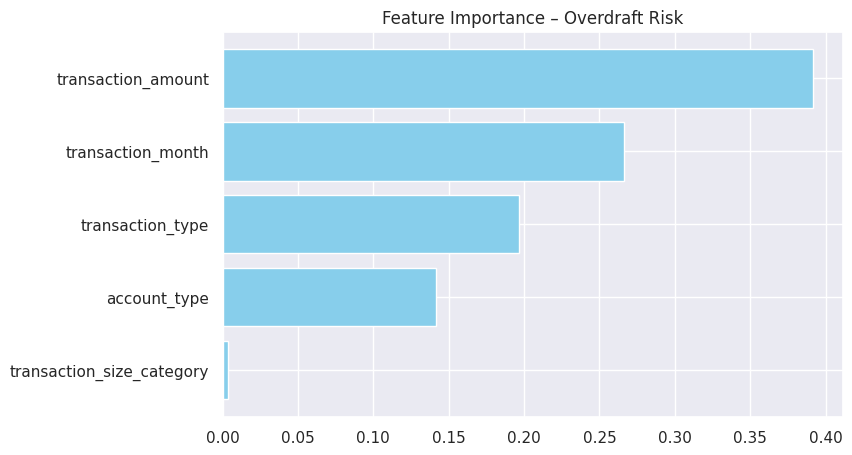


CUSTOMER CLUSTERING ANALYSIS


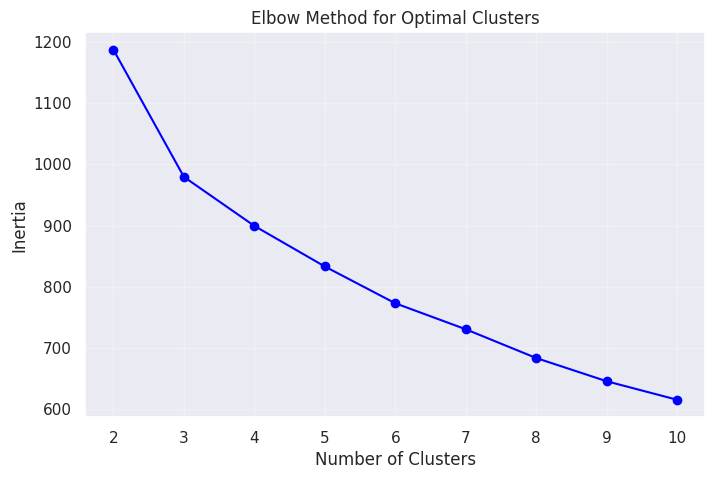


Cluster Summary:
         transaction_amount_mean  transaction_amount_std  \
cluster                                                    
0                   53430.943902            29345.777561   
1                   41676.167241            28008.676207   
2                   51027.642537            25626.320597   
3                   62594.630851            29471.296809   

         transaction_amount_sum  transaction_amount_count  \
cluster                                                     
0                 131135.002683                  2.658537   
1                 104770.302069                  2.482759   
2                 222080.634627                  4.477612   
3                 418336.021489                  6.787234   

         account_balance_mean  account_balance_min  account_balance_max  \
cluster                                                                   
0                48588.344634         26411.733902         67466.823415   
1                99498.899310

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

class AdvancedAnalytics:
    def __init__(self, df):
        self.df = df

    def predictive_risk_modeling(self):
        print("\n" + "="*60)
        print("PREDICTIVE RISK MODELING")
        print("="*60)

        from sklearn.model_selection import train_test_split
        from sklearn.ensemble import RandomForestClassifier
        from sklearn.metrics import classification_report
        from sklearn.preprocessing import LabelEncoder

        features_df = self.df.copy()

        # ✅ Create overdraft target
        features_df['is_overdraft'] = (features_df['account_balance'] < 0).astype(int)

        # ✅ Create transaction size category
        features_df['transaction_size_category'] = pd.cut(
            features_df['transaction_amount'],
            bins=[-1, 100, 1000, np.inf],
            labels=['Small', 'Medium', 'Large']
        )

        feature_cols = [
            'transaction_amount',
            'transaction_type',
            'account_type',
            'transaction_size_category',
            'transaction_month'
        ]

        # Encode categoricals
        for col in ['transaction_type', 'account_type', 'transaction_size_category']:
            le = LabelEncoder()
            features_df[col] = le.fit_transform(features_df[col].astype(str))

        X = features_df[feature_cols]
        y = features_df['is_overdraft']

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )

        print("Training Random Forest Classifier...")
        model = RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            class_weight='balanced'
        )
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        print("\nModel Performance:")
        print(classification_report(y_test, y_pred))

        # Feature importance
        feature_importance = pd.DataFrame({
            'feature': feature_cols,
            'importance': model.feature_importances_
        }).sort_values('importance', ascending=False)

        plt.figure(figsize=(8, 5))
        plt.barh(feature_importance['feature'], feature_importance['importance'], color='skyblue')
        plt.title('Feature Importance – Overdraft Risk')
        plt.gca().invert_yaxis()
        plt.show()

        return model, feature_importance

    def customer_clustering(self):
        print("\n" + "="*60)
        print("CUSTOMER CLUSTERING ANALYSIS")
        print("="*60)

        from sklearn.cluster import KMeans
        from sklearn.preprocessing import StandardScaler

        customer_features = self.df.groupby('customer_id').agg({
            'transaction_amount': ['mean', 'std', 'sum', 'count'],
            'account_balance': ['mean', 'min', 'max'],
            'risk_score': 'mean',
            'transaction_type': lambda x: (x == 'Debit').sum() / len(x)
        }).round(2)

        customer_features.columns = [
            '_'.join(col).strip() for col in customer_features.columns
        ]

        # Handle missing values
        customer_features.fillna(customer_features.median(), inplace=True)

        # Standardize features
        scaler = StandardScaler()
        scaled_features = scaler.fit_transform(customer_features)

        # Elbow method
        inertias = []
        for k in range(2, 11):
            km = KMeans(n_clusters=k, random_state=42, n_init=10)
            km.fit(scaled_features)
            inertias.append(km.inertia_)

        plt.figure(figsize=(8,5))
        plt.plot(range(2, 11), inertias, marker='o', color='blue')
        plt.title('Elbow Method for Optimal Clusters')
        plt.xlabel('Number of Clusters')
        plt.ylabel('Inertia')
        plt.grid(True, alpha=0.3)
        plt.show()

        # Apply final clustering
        kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
        customer_features['cluster'] = kmeans.fit_predict(scaled_features)

        cluster_summary = customer_features.groupby('cluster').mean()

        print("\nCluster Summary:")
        print(cluster_summary)

        return customer_features, cluster_summary

# =========================
# Usage
# =========================
analytics = AdvancedAnalytics(df_clean)

# Predictive risk modeling
rf_model, feature_importance = analytics.predictive_risk_modeling()

# Customer clustering
customer_clusters, cluster_summary = analytics.customer_clustering()


In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class ReportGenerator:
    def __init__(self, df, analysis_results):
        self.df = df.copy()
        self.results = analysis_results

        # Derived fields
        self.df['balance_status'] = np.where(
            self.df['account_balance'] < 0, 'Overdraft',
            np.where(self.df['account_balance'] < 100, 'Low Balance', 'Normal')
        )

        self.df['transaction_size_category'] = pd.cut(
            self.df['transaction_amount'],
            bins=[-1, 100, 1000, np.inf],
            labels=['Small', 'Medium', 'Large']
        )

    def generate_executive_summary(self):
        total_txn = len(self.df)
        total_customers = self.df['customer_id'].nunique()
        overdrafts = (self.df['balance_status'] == 'Overdraft').sum()
        print("\n📊 KEY METRICS")
        print(f"Total Transactions: {total_txn:,}")
        print(f"Unique Customers: {total_customers}")
        print(f"Overdraft Incidents: {overdrafts}")

        # Risk summary table
        high_risk = self.results.get('high_risk_customers', pd.DataFrame())
        risk_summary = pd.DataFrame({
            'Metric': ['High Risk Customers', 'Overdraft Rate'],
            'Value': [
                f"{len(high_risk)} ({len(high_risk)/total_customers*100:.1f}%)",
                f"{overdrafts/total_txn*100:.2f}%"
            ]
        })
        print("\n📈 RISK METRICS SUMMARY")
        print(risk_summary.to_string(index=False))
        return risk_summary

    def generate_visual_dashboard(self):
        fig = plt.figure(figsize=(20, 12))
        gs = fig.add_gridspec(3, 4)

        # Monthly Transaction Volume
        ax1 = fig.add_subplot(gs[0, :3])
        self.df.groupby('transaction_month')['transaction_amount'].sum().plot(ax=ax1)
        ax1.set_title('Monthly Transaction Volume')

        # Account Type Distribution
        ax2 = fig.add_subplot(gs[0, 3])
        self.df['account_type'].value_counts().plot.pie(autopct='%1.1f%%', ax=ax2)
        ax2.set_title('Account Type Distribution')

        # Risk Score Distribution
        ax3 = fig.add_subplot(gs[1, 0])
        ax3.hist(self.df['risk_score'], bins=30, color='skyblue', edgecolor='black')
        ax3.set_title('Risk Score Distribution')

        # Balance Status
        ax4 = fig.add_subplot(gs[1, 1])
        self.df['balance_status'].value_counts().plot.pie(autopct='%1.1f%%', ax=ax4)
        ax4.set_title('Balance Status')

        # Transaction Size Distribution
        ax5 = fig.add_subplot(gs[1, 2:])
        self.df['transaction_size_category'].value_counts().plot.bar(ax=ax5)
        ax5.set_title('Transaction Size Distribution')

        # Debit vs Credit by Account Type
        ax6 = fig.add_subplot(gs[2, :2])
        pd.crosstab(
            self.df['account_type'],
            self.df['transaction_type'],
            values=self.df['transaction_amount'],
            aggfunc='mean'
        ).plot(kind='bar', ax=ax6)
        ax6.set_title('Avg Amount: Debit vs Credit')

        # KPI box
        ax7 = fig.add_subplot(gs[2, 2:])
        ax7.axis('off')
        ax7.text(
            0.05, 0.5,
            f"Customers: {self.df['customer_id'].nunique()}\n"
            f"Transactions: {len(self.df):,}\n"
            f"Overdraft Rate: {(self.df['balance_status']=='Overdraft').mean()*100:.2f}%\n"
            f"Avg Risk Score: {self.df['risk_score'].mean():.2f}/10",
            fontsize=12
        )

        plt.suptitle(
            'BARCLAYS FINANCIAL BEHAVIOR & RISK DASHBOARD',
            fontsize=18, fontweight='bold'
        )
        plt.tight_layout()
        plt.show()




PREDICTIVE RISK MODELING
Training Random Forest Classifier...

Model Performance:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       157
           1       0.00      0.00      0.00         3

    accuracy                           0.98       160
   macro avg       0.49      0.50      0.50       160
weighted avg       0.96      0.98      0.97       160



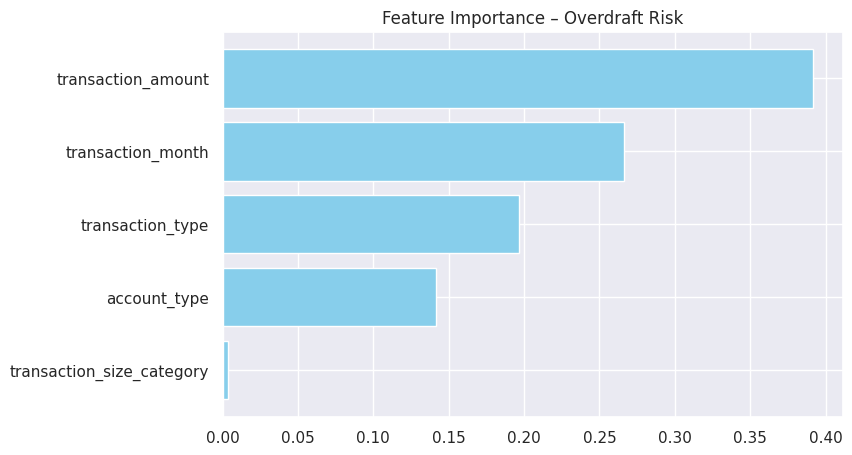


CUSTOMER CLUSTERING ANALYSIS


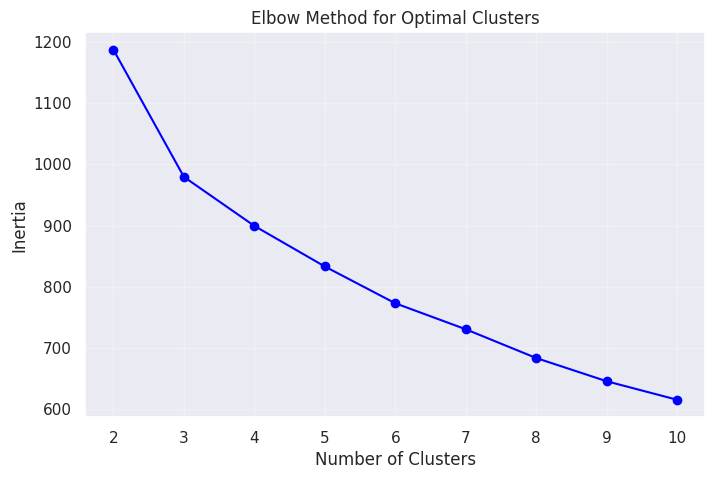


Cluster Summary:
         transaction_amount_mean  transaction_amount_std  \
cluster                                                    
0                   53430.943902            29345.777561   
1                   41676.167241            28008.676207   
2                   51027.642537            25626.320597   
3                   62594.630851            29471.296809   

         transaction_amount_sum  transaction_amount_count  \
cluster                                                     
0                 131135.002683                  2.658537   
1                 104770.302069                  2.482759   
2                 222080.634627                  4.477612   
3                 418336.021489                  6.787234   

         account_balance_mean  account_balance_min  account_balance_max  \
cluster                                                                   
0                48588.344634         26411.733902         67466.823415   
1                99498.899310

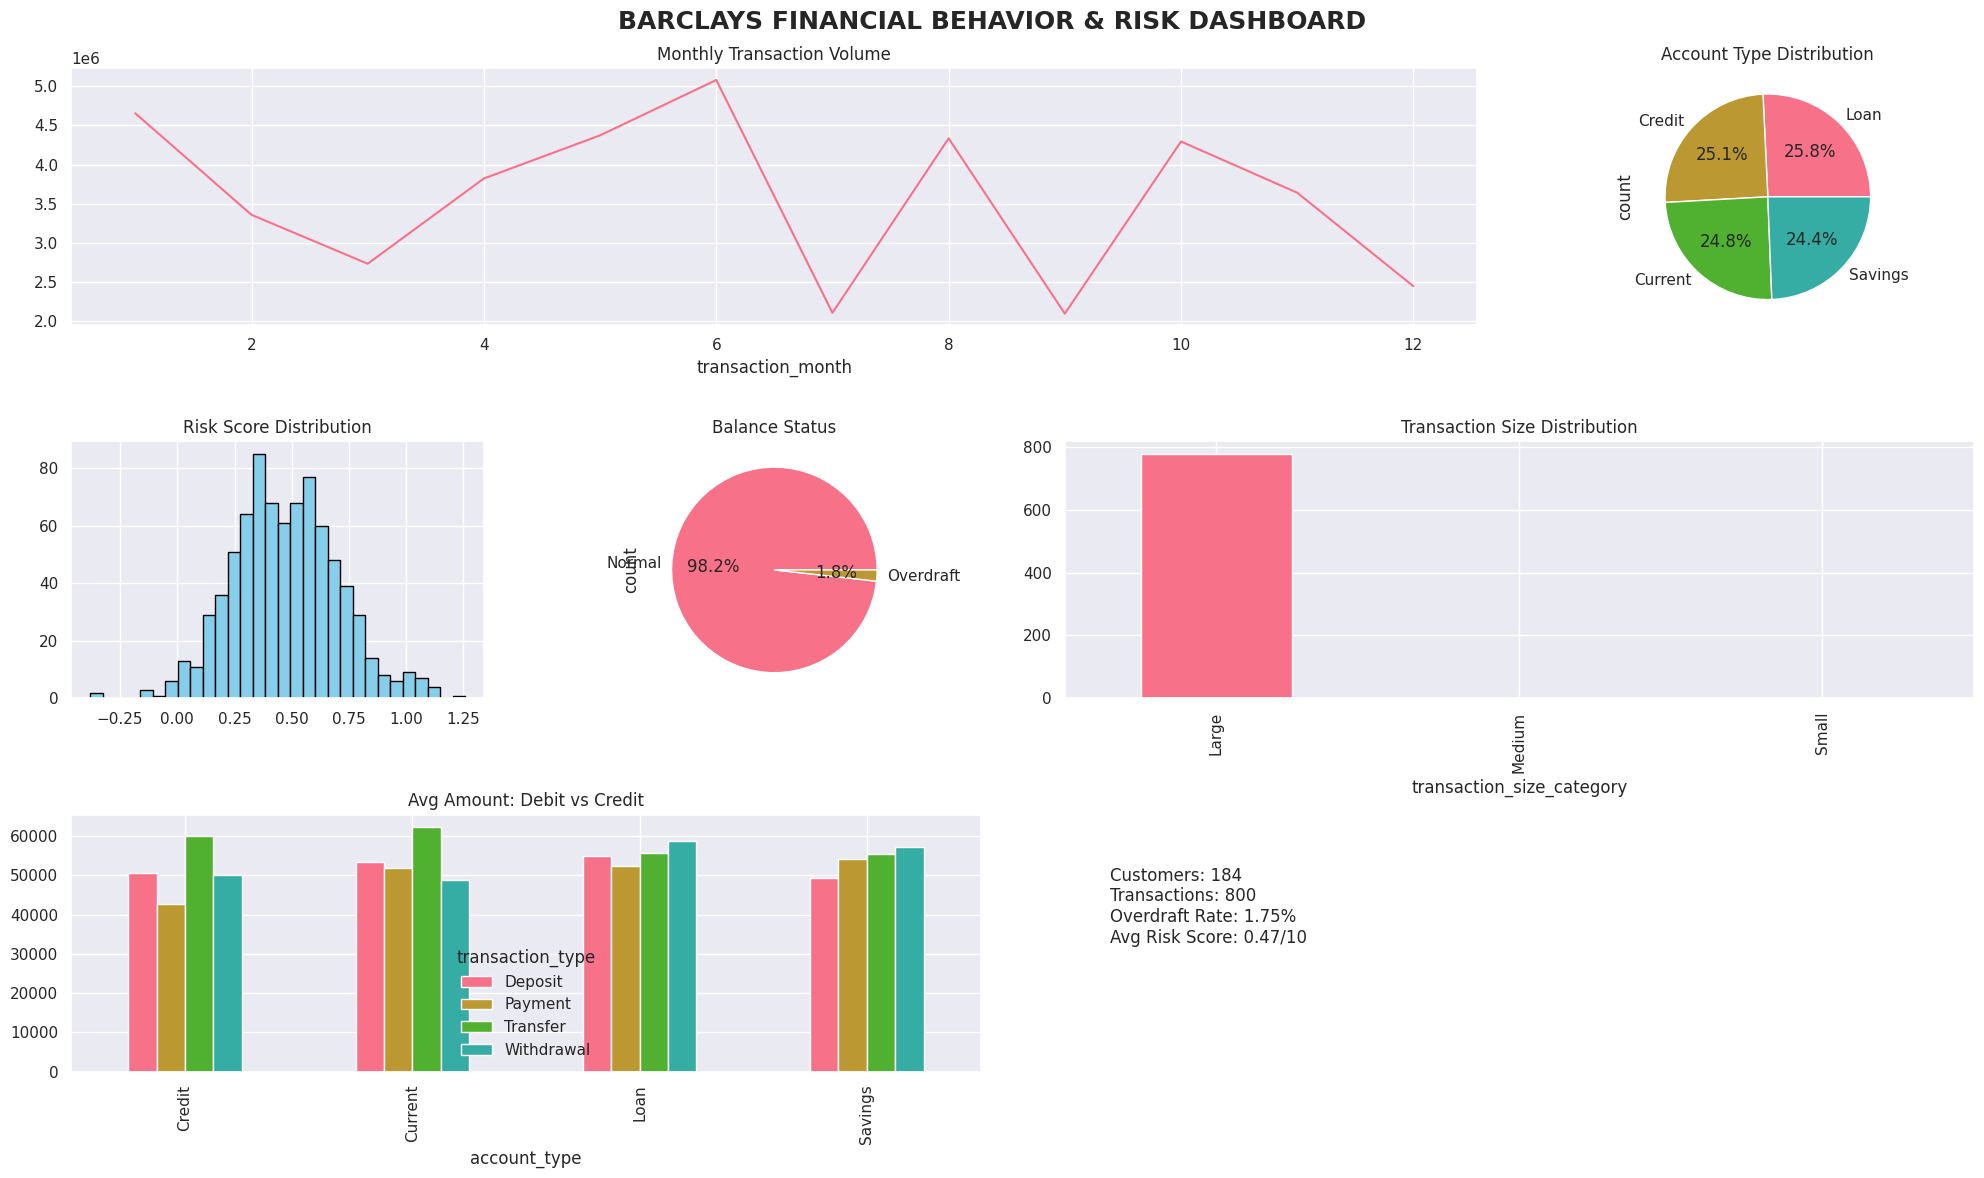

In [39]:
# Assuming AdvancedAnalytics and df_clean are already available

# 1️⃣ Perform predictive modeling
analytics = AdvancedAnalytics(df_clean)
rf_model, feature_importance = analytics.predictive_risk_modeling()

# 2️⃣ Perform customer clustering
customer_clusters, cluster_summary = analytics.customer_clustering()

# 3️⃣ Collect analysis results
analysis_results = {
    'high_risk_customers': None,  # If you have high_risk_accounts from RiskAnalyzer, put it here
    'customer_risk_metrics': None,
    'overdraft_patterns': None,
    'feature_importance': feature_importance,
    'customer_clusters': customer_clusters
}
analysis_results = {
    'high_risk_customers': high_risk_accounts if 'high_risk_accounts' in locals() else pd.DataFrame(),
    'customer_risk_metrics': customer_risk_metrics if 'customer_risk_metrics' in locals() else pd.DataFrame(),
    'overdraft_patterns': overdraft_patterns if 'overdraft_patterns' in locals() else pd.DataFrame(),
    'feature_importance': feature_importance if 'feature_importance' in locals() else pd.DataFrame(),
    'customer_clusters': customer_clusters if 'customer_clusters' in locals() else pd.DataFrame()
}

# 4️⃣ Generate report
report = ReportGenerator(df_clean, analysis_results)
report.generate_executive_summary()
report.generate_visual_dashboard()
